#### Imports & Setup

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyomo.environ import *
from DataTask7 import fetch_data

#### Load data

In [34]:
def load_data():
    # ── System parameters ──────────────────────────────────────────
    params = fetch_data()  
    
    # Unpack into variables
    T        = params['num_timeslots']        # 10 hours
    N        = 15                             # number of stores
    R        = 2                              # rooms per store
    
    P_mall   = params['P_mall']               # 45 kW
    T_ref    = params['Temperature_reference'] # 21°C
    T_init   = params['initial_temperature']  # 21°C (same all stores/rooms)
    P_max    = params['heating_max_power']    # 3.0 kW per heater
    
    zeta_exch = params['heat_exchange_coeff']      # 0.6
    zeta_conv = params['heating_efficiency_coeff'] # 1.0
    zeta_loss = params['thermal_loss_coeff']       # 0.1
    zeta_cool = params['heat_vent_coeff']          # 0.7 (always ON, fixed)
    zeta_occ  = params['heat_occupancy_coeff']     # 0.02
    
    # Outdoor temperature: list of 10 values, one per hour
    T_out = np.array(params['outdoor_temperature'])  # shape: (10,)
    
    # ── Occupancy ──────────────────────────────────────────────────
    # Read CSV: skip header row, last column is room label
    occ_df = pd.read_csv(
        'Task7Occupancies.csv',
        header=0,        # first row is hour labels (0-9)
        index_col=False
    )
    
    # The file has 10 numeric columns + 1 label column at the end
    # Extract just the numeric columns (hours 0-9)
    occ_room1 = occ_df.iloc[0, :10].values.astype(float)  # shape: (10,)
    occ_room2 = occ_df.iloc[1, :10].values.astype(float)  # shape: (10,)
    
    # Stack into shape (2, 10): occ[r, t]
    # occ[0, t] = room 1 occupancy at hour t
    # occ[1, t] = room 2 occupancy at hour t
    occ = np.stack([occ_room1, occ_room2], axis=0)  # shape: (2, 10)
    
    # ── Weights ────────────────────────────────────────────────────
    weights = np.array([n + 2 for n in range(N)])  
    # weights = [2, 3, 4, ..., 16]
    
    return {
        'T': T,           # number of hours (10)
        'N': N,           # number of stores (15)
        'R': R,           # number of rooms (2)
        'P_mall': P_mall,
        'T_ref': T_ref,
        'T_init': T_init,
        'P_max': P_max,
        'zeta_exch': zeta_exch,
        'zeta_conv': zeta_conv,
        'zeta_loss': zeta_loss,
        'zeta_cool': zeta_cool,
        'zeta_occ': zeta_occ,
        'T_out': T_out,   # shape: (10,)
        'occ': occ,       # shape: (2, 10)
        'weights': weights # shape: (15,)
    }

### Centralized problem (benchmark)
Solves the centralized optimization problem for all 15 stores jointly.
Returns the optimal objective value (the benchmark).

In [35]:
def solve_centralized(data):
    
    # ── Unpack data ────────────────────────────────────────────────
    N         = data['N']           # 15 stores
    T         = data['T']           # 10 hours
    P_mall    = data['P_mall']      # 45 kW
    T_ref     = data['T_ref']       # 21°C
    T_init    = data['T_init']      # 21°C
    P_max     = data['P_max']       # 3.0 kW
    zeta_exch = data['zeta_exch']   # 0.6
    zeta_conv = data['zeta_conv']   # 1.0
    zeta_loss = data['zeta_loss']   # 0.1
    zeta_cool = data['zeta_cool']   # 0.7
    zeta_occ  = data['zeta_occ']    # 0.02
    T_out     = data['T_out']       # shape (10,)
    occ       = data['occ']         # shape (2, 10)
    weights   = data['weights']     # shape (15,)

    # ── Build Pyomo model ──────────────────────────────────────────
    model = ConcreteModel()

    # ── Index sets ─────────────────────────────────────────────────
    model.N = range(N)    # 0..14  stores
    model.R = range(2)    # 0..1   rooms
    model.T = range(T)    # 0..9   hours

    # ── Decision Variables ─────────────────────────────────────────
    
    # Heater power: p[n, r, t] in [0, P_max]
    model.p = Var(
        model.N, model.R, model.T,
        domain=NonNegativeReals,
        bounds=(0, P_max)
    )
    
    # Room temperature: T_room[n, r, t] — free real variable
    model.T_room = Var(
        model.N, model.R, model.T,
        domain=Reals
    )

    # ── Objective ──────────────────────────────────────────────────
    # Minimize weighted squared deviation from T_ref
    def objective_rule(model):
        return sum(
            weights[n] * (
                (model.T_room[n, 0, t] - T_ref) ** 2 +
                (model.T_room[n, 1, t] - T_ref) ** 2
            )
            for n in model.N
            for t in model.T
        )
    
    model.objective = Objective(rule=objective_rule, sense=minimize)

    # ── Constraint 1: Temperature Dynamics ─────────────────────────
    # Only applies for t >= 1 (t=0 is the initial condition)
    # r=0 exchanges heat with r=1, and vice versa
    def dynamics_rule(model, n, r, t):
        if t == 0:
            # At hour 0: temperature equals initial condition
            # This is an equality fixing T_room[n,r,0] = T_init
            return model.T_room[n, r, t] == T_init
        else:
            r_other = 1 if r == 0 else 0   # the other room
            return model.T_room[n, r, t] == (
                model.T_room[n, r, t-1]
                + zeta_exch * (model.T_room[n, r_other, t-1] - model.T_room[n, r, t-1])
                + zeta_loss * (T_out[t-1]                    - model.T_room[n, r, t-1])
                + zeta_conv * model.p[n, r, t-1]
                - zeta_cool
                + zeta_occ  * occ[r, t-1]
            )
    
    model.dynamics = Constraint(model.N, model.R, model.T, rule=dynamics_rule)

    # ── Constraint 2: Mall Power Cap ───────────────────────────────
    # Total power across all stores and rooms cannot exceed P_mall
    # One constraint per hour
    def power_cap_rule(model, t):
        return sum(
            model.p[n, r, t]
            for n in model.N
            for r in model.R
        ) <= P_mall
    
    model.power_cap = Constraint(model.T, rule=power_cap_rule)

    # ── Solve ──────────────────────────────────────────────────────
    solver = SolverFactory('gurobi')
    solver.options['OutputFlag'] = 0    
    solver.options['NonConvex'] = 2     
    
    result = solver.solve(model)

    if result.solver.termination_condition != 'optimal':
        raise RuntimeError(f"Centralized solve failed: {result.solver.termination_condition}")

    # ── Extract results ────────────────────────────────────────────
    obj_value = value(model.objective)
    
    # extract the optimal power schedule 
    # Shape: (N, 2, T) — stores × rooms × hours


    p_optimal = np.array([
        [[value(model.p[n, r, t]) for t in model.T]
                              for r in model.R]
                              for n in model.N
    ])
    T_optimal = np.array([
        [[value(model.T_room[n, r, t]) for t in model.T]
                                   for r in model.R]
                                   for n in model.N
    ])
    return obj_value, p_optimal, T_optimal

### Store subproblem (function)

Solves the Lagrangian subproblem for store n.

**Parameters**
- `n` *(int)* — store index, 0-based (store 1 = index 0, store 15 = index 14)
- `lambda_t` *(np.ndarray, shape (T,))* — dual variables from the coordinator, one per hour
- `data` *(dict)* — problem data returned by `load_data()`

**Returns**
- `p_store` *(np.ndarray, shape (2, T))* — optimal heater power for each room and hour
- `T_store` *(np.ndarray, shape (2, T))* — room temperatures resulting from `p_store`
- `obj_local` *(float)* — primal comfort cost for this store, lambda terms excluded

In [36]:
def solve_store(n, lambda_t, data):
    
    T_ref     = data['T_ref']
    T_init    = data['T_init']
    P_max     = data['P_max']
    zeta_exch = data['zeta_exch']
    zeta_conv = data['zeta_conv']
    zeta_loss = data['zeta_loss']
    zeta_cool = data['zeta_cool']
    zeta_occ  = data['zeta_occ']
    T_out     = data['T_out']
    occ       = data['occ']
    weights   = data['weights']
    w_n       = weights[n]
    num_hours = data['T']
    
    model = ConcreteModel()
    model.R = range(2)
    model.T = range(num_hours)

    # ── Variables ──────────────────────────────────────────────────
    # Initialize p to 0 explicitly (prevents uninitialized variable errors)
    model.p = Var(
        model.R, model.T,
        domain=NonNegativeReals,
        bounds=(0, P_max),
        initialize=0.0 
    )
    
    model.T_room = Var(
        model.R, model.T,
        domain=Reals,
        initialize=T_init 
    )

    # ── Objective ──────────────────────────────────────────────────
    def objective_rule(model):
        
        comfort_cost = sum(
            w_n * (
                (model.T_room[0, t] - T_ref) ** 2 +
                (model.T_room[1, t] - T_ref) ** 2
            )
            for t in model.T
        )

        energy_cost = sum(
            lambda_t[t] * (model.p[0, t] + model.p[1, t])
            for t in model.T
        )
        return comfort_cost + energy_cost
    
    model.objective = Objective(rule=objective_rule, sense=minimize)

    # ── Dynamics ───────────────────────────────────────────────────
    def dynamics_rule(model, r, t):
        if t == 0:
            return model.T_room[r, t] == T_init
        else:
            r_other = 1 if r == 0 else 0
            return model.T_room[r, t] == (
                model.T_room[r, t-1]
                + zeta_exch * (model.T_room[r_other, t-1] - model.T_room[r, t-1])
                + zeta_loss * (T_out[t-1]                 - model.T_room[r, t-1])
                + zeta_conv * model.p[r, t-1]
                - zeta_cool
                + zeta_occ  * occ[r, t-1]
            )
    
    model.dynamics = Constraint(model.R, model.T, rule=dynamics_rule)

    # ── Solve ──────────────────────────────────────────────────────
    solver = SolverFactory('gurobi')
    solver.options['OutputFlag'] = 0
    solver.options['NonConvex']  = 2
    
    result = solver.solve(model)
    
    # ── Check solver status before extracting ─────────────────────
    status = result.solver.status
    termination = result.solver.termination_condition
    
    if termination != 'optimal':
        print(f"  WARNING: Store {n} solver status: {status}, "
              f"termination: {termination}")
        return np.zeros((2, num_hours)), np.full((2, num_hours), T_init), 0.0

    # ── Extract results ────────────────────────────────────────────
    p_store = np.array([
        [value(model.p[r, t]) for t in model.T]
        for r in model.R
    ])
    
    T_store = np.array([
        [value(model.T_room[r, t]) for t in model.T]
        for r in model.R
    ])

    obj_local = sum(
        w_n * (
            (T_store[0, t] - T_ref) ** 2 +
            (T_store[1, t] - T_ref) ** 2
        )
        for t in range(num_hours)
    )
    
    return p_store, T_store, obj_local

### Distributed loop (function)

In [37]:
def run_distributed(alpha, data, n_iterations=100):
    """
    Runs the distributed optimization algorithm.
    
    Parameters:
        alpha        : either a float (fixed step size)
                       or the string 'adaptive' for alpha_k = 5/(1+k)
        data         : dictionary from load_data()
        n_iterations : number of iterations (default 100)
    
    Returns:
        history_obj       : array of shape (n_iterations,)
                            total comfort cost at each iteration
        history_lambda    : array of shape (n_iterations, 10)
                            price vector at each iteration
        history_violation : array of shape (n_iterations, 10)
                            constraint violation per hour at each iteration
    """
    
    # ── Unpack needed data ─────────────────────────────────────────
    N      = data['N']        # 15 stores
    T      = data['T']        # 10 hours
    P_mall = data['P_mall']   # 45 kW
    
    # ── Initialize prices ──────────────────────────────────────────
    lambda_t = np.zeros(T)   # shape (10,)
    
    # ── Initialize history arrays ──────────────────────────────────
    history_obj       = np.zeros(n_iterations)
    history_lambda    = np.zeros((n_iterations, T))
    history_violation = np.zeros((n_iterations, T))
    
    # ── Main iteration loop ────────────────────────────────────────
    for k in range(n_iterations):
        
        # ── Step A: Compute step size ──────────────────────────────
        if alpha == 'adaptive':
            alpha_k = 5.0 / (1 + k)
        else:
            alpha_k = alpha
        
        # ── Step B: Each store solves its subproblem ───────────────
        all_p     = np.zeros((N, 2, T))
        total_obj = 0.0
        
        for n in range(N):
            p_store, T_store, obj_local = solve_store(n, lambda_t, data)
            all_p[n]   = p_store
            total_obj += obj_local
        
        # ── Step C: Coordinator aggregates ─────────────────────────
        total_power = all_p.sum(axis=(0, 1))   # clearer
        violation   = total_power - P_mall             # shape (10,)
        
        # ── Step D: Record history ─────────────────────────────────
        history_obj[k]       = total_obj
        history_lambda[k]    = lambda_t.copy()
        history_violation[k] = violation.copy()
        
        # ── Step E: Update prices ──────────────────────────────────
        lambda_t = np.maximum(0, lambda_t + alpha_k * violation)
        
        # ── Progress print ─────────────────────────────────────────
        if (k + 1) % 5 == 0:
            print(f"  Iteration {k+1:3d} | "
                  f"Obj: {total_obj:10.4f} | "
                  f"Max violation: {violation.max():8.4f} | "
                  f"Max lambda: {lambda_t.max():8.4f}")

    # ── Final signed violation summary — OUTSIDE THE LOOP ─────────
    print(f"\n  Signed violations at final iteration:")
    print(f"  (negative = under cap/slack, positive = over cap/violated)")
    for t in range(T):
        signed = history_violation[-1][t]
        if signed > 0.01:
            status = "VIOLATED"
        elif signed < -0.01:
            status = "slack"
        else:
            status = "exact"
        print(f"    Hour {t}: {signed:+.7f} kW  [{status}]")

    return history_obj, history_lambda, history_violation

### Running the Experiments

In [38]:
def run_experiments(data, n_iterations=100):
    """
    Runs all experiments: centralized benchmark + 
    distributed algorithm for all alpha values.
    
    Parameters:
        data         : dictionary from load_data()
        n_iterations : number of iterations per run (default 100)
    
    Returns:
        obj_centralized : float — optimal benchmark objective value
        results         : dict — all distributed run histories
    """
    
    # ── Step 1: Solve Centralized Problem ──────────────────────────
    print("=" * 60)
    print("Solving centralized problem...")
    print("=" * 60)
    
    obj_centralized, p_optimal, T_optimal = solve_centralized(data)
    
    # ── Centralized Printing Block ─────────────────────────────────
    print("=" * 60)
    print("CENTRALIZED SOLUTION SUMMARY")
    print("=" * 60)
    print(f"Optimal objective value: {obj_centralized:.4f}")
    print(f"(Lower is better — 0 means perfect comfort everywhere)")
    print()

    total_power_per_hour = p_optimal.sum(axis=0).sum(axis=0)
    print("Power consumption per hour (all stores combined):")
    print(f"  {'Hour':<6} {'Total kW':>10} {'Cap':>8} {'Headroom':>10}")
    print(f"  {'-'*36}")
    for t in range(data['T']):
        headroom = data['P_mall'] - total_power_per_hour[t]
        flag = " ← CAP HIT" if headroom < 0.01 else ""
        print(f"  {t:<6} {total_power_per_hour[t]:>10.3f} "
              f"{data['P_mall']:>8.1f} {headroom:>10.3f}{flag}")
    print(f"  {'-'*36}")
    print(f"  Average total power: {total_power_per_hour.mean():.3f} kW")
    print(f"  Peak total power:    {total_power_per_hour.max():.3f} kW")
    print()

    T_ref     = data['T_ref']
    T_init    = data['T_init']
    zeta_exch = data['zeta_exch']
    zeta_conv = data['zeta_conv']
    zeta_loss = data['zeta_loss']
    zeta_cool = data['zeta_cool']
    zeta_occ  = data['zeta_occ']
    T_out     = data['T_out']
    occ       = data['occ']
    weights   = data['weights']


    T_avg = (T_optimal[:, 0, :] + T_optimal[:, 1, :]) / 2


    print("Per-store summary:")
    print(f"  {'Store':<7} {'Weight':>7} {'Avg Temp':>10} "
          f"{'Min Temp':>10} {'Max Temp':>10} {'Comfort Cost':>14}")
    print(f"  {'-'*62}")
    for n in range(data['N']):
        avg_temp = T_avg[n].mean()
        min_temp = T_avg[n].min()
        max_temp = T_avg[n].max()

        cost_n = weights[n] * (
            ((T_optimal[n, 0, :] + T_optimal[n, 1, :]) / 2 - T_ref) ** 2
        ).sum()
        
        print(f"  {n+1:<7} {weights[n]:>7} {avg_temp:>10.3f} "
              f"{min_temp:>10.3f} {max_temp:>10.3f} {cost_n:>14.4f}")
    print(f"  {'-'*62}")
    print(f"  {'Total comfort cost:':>47} {obj_centralized:>14.4f}")
    print()

    avg_temps_overall = T_avg.mean(axis=1)
    coldest_stores = np.argsort(avg_temps_overall)
    print("Stores ranked coldest to warmest (day average):")
    for rank, n in enumerate(coldest_stores):
        bar_length = int((avg_temps_overall[n] / T_ref) * 20)
        bar = "█" * bar_length
        print(f"  Rank {rank+1:2d} | Store {n+1:2d} "
              f"(w={weights[n]:2d}) | "
              f"{avg_temps_overall[n]:.3f}°C | {bar}")
    print()

    total_power_per_store = p_optimal.sum(axis=1).sum(axis=1)
    print("Total energy used per store over the day (kWh):")
    most_power = np.argsort(total_power_per_store)[::-1]
    for n in most_power:
        bar_length = int(total_power_per_store[n] / p_optimal.sum() * 40)
        bar = "█" * bar_length
        print(f"  Store {n+1:2d} (w={weights[n]:2d}) | "
              f"{total_power_per_store[n]:6.2f} kWh | {bar}")

    total_energy_used = p_optimal.sum()
    total_energy_cap  = data['P_mall'] * (data['T'] - 1)
    print(f"\n  Total energy used:      {total_energy_used:.2f} kWh")
    print(f"  Total energy available: {total_energy_cap:.2f} kWh")
    print(f"  Utilization:            {100 * total_energy_used / total_energy_cap:.1f}%")
    print()

    # ── Step 2: Define Alpha Values ────────────────────────────────
    alphas = [0.001, 0.01, 0.1, 1, 10, 'adaptive']

    # ── Step 3: Run Distributed Algorithm for Each Alpha ──────────
    results = {}

    for alpha in alphas:
        print("=" * 60)
        print(f"Running distributed algorithm | alpha = {alpha}")
        print("=" * 60)

        history_obj, history_lambda, history_violation = run_distributed(
            alpha        = alpha,
            data         = data,
            n_iterations = n_iterations
        )

        results[alpha] = {
            'obj'       : history_obj,
            'lambda'    : history_lambda,
            'violation' : history_violation
        }

        final_violation = history_violation[-1]
        max_positive    = max(0, final_violation.max())
        max_slack       = abs(min(0, final_violation.min()))
        is_feasible     = max_positive < 0.01

        print(f"  Final objective:      {history_obj[-1]:.4f}")
        print(f"  Centralized optimal:  {obj_centralized:.4f}")
        print(f"  Gap:                  {history_obj[-1] - obj_centralized:.4f}")
        print(f"  Feasible:             {'YES ✓' if is_feasible else 'NO ✗ (constraint violated)'}")
        print(f"  Max positive violation: {max_positive:.4f} kW")
        print(f"  Max slack:              {max_slack:.4f} kW")
        print(f"  Signed violation per hour:")
        for t in range(data['T']):
            signed = final_violation[t]
            if signed > 0.01:
                status = "VIOLATED"
            elif signed < -0.01:
                status = "slack"
            else:
                status = "exact"
            print(f"    Hour {t}: {signed:+.4f} kW  [{status}]")
        print()

    return obj_centralized, results

### Create plots

In [39]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

def create_plots(obj_centralized, results, data):
    """
    Creates all required plots for Task 7.

    Figure 1a: Objective vs iterations — 5 fixed alpha curves + benchmark
    Figure 1b: Objective vs iterations — adaptive alpha + benchmark
    Figure 2:  Lambda evolution (2x3 grid) — all six step‑size strategies
    Figure 3:  Constraint violation (2x3 grid) — all six step‑size strategies
    """

    fixed_alphas = [0.001, 0.01, 0.1, 1, 10]
    T            = data['T']
    n_iter       = len(results[0.001]['obj'])
    iterations   = np.arange(1, n_iter + 1)

    # ── Color and style map ────────────────────────────────────────
    style_map = {
        0.001:      {'color': '#378ADD', 'ls': '-',   'lw': 1.5, 'label': 'α = 0.001'},
        0.01:       {'color': '#1D9E75', 'ls': '--',  'lw': 1.5, 'label': 'α = 0.01'},
        0.1:        {'color': '#BA7517', 'ls': '-.',  'lw': 1.5, 'label': 'α = 0.1'},
        1:          {'color': '#D4537E', 'ls': ':',   'lw': 1.5, 'label': 'α = 1'},
        10:         {'color': '#7F77DD', 'ls': '-',   'lw': 1.5, 'label': 'α = 10'},
        'adaptive': {'color': '#2C2C2A', 'ls': '--',  'lw': 2.2, 'label': 'α = 5/(1+k)'},
    }

    # ── Hour colors — one per timeslot ────────────────────────────
    hour_colors = plt.cm.tab10(np.linspace(0, 1, T))

    # ── Shared hour legend handles ─────────────────────────────────
    hour_handles = [
        mlines.Line2D([], [], color=hour_colors[t], linewidth=1.5, label=f'Hour {t}')
        for t in range(T)
    ]

    # ═══════════════════════════════════════════════════════════════
    # FIGURE 1a — Objective vs iterations, five fixed alphas
    # ═══════════════════════════════════════════════════════════════
    fig1a, ax1a = plt.subplots(figsize=(10, 5))

    for alpha in fixed_alphas:
        s = style_map[alpha]
        ax1a.plot(
            iterations,
            results[alpha]['obj'],
            color=s['color'],
            linestyle=s['ls'],
            linewidth=s['lw'],
            label=s['label']
        )

    ax1a.axhline(
        y=obj_centralized,
        color='red',
        linestyle='-',
        linewidth=1.5,
        label=f'Centralized optimal ({obj_centralized:.0f})'
    )

    ax1a.set_xlabel('Iteration', fontsize=12)
    ax1a.set_ylabel('Objective value (weighted squared deviation)', fontsize=12)
    ax1a.set_title('Objective value vs iterations — fixed α ∈ {0.001, 0.01, 0.1, 1, 10}', fontsize=13)
    ax1a.legend(loc='upper right', fontsize=10)
    ax1a.set_xlim([1, n_iter])
    ax1a.grid(True, alpha=0.3)
    fig1a.tight_layout()
    fig1a.savefig('task7_fig1a_objective_fixed.png', dpi=150, bbox_inches='tight')
    print("Figure 1a saved.")

    # ═══════════════════════════════════════════════════════════════
    # FIGURE 1b — Objective vs iterations, adaptive alpha
    # ═══════════════════════════════════════════════════════════════
    fig1b, ax1b = plt.subplots(figsize=(10, 5))

    s = style_map['adaptive']
    ax1b.plot(
        iterations,
        results['adaptive']['obj'],
        color=s['color'],
        linestyle=s['ls'],
        linewidth=s['lw'],
        label=s['label']
    )

    ax1b.axhline(
        y=obj_centralized,
        color='red',
        linestyle='-',
        linewidth=1.5,
        label=f'Centralized optimal ({obj_centralized:.0f})'
    )

    ax1b.set_xlabel('Iteration', fontsize=12)
    ax1b.set_ylabel('Objective value (weighted squared deviation)', fontsize=12)
    ax1b.set_title('Objective value vs iterations — adaptive α = 5/(1+k)', fontsize=13)
    ax1b.legend(loc='upper right', fontsize=10)
    ax1b.set_xlim([1, n_iter])
    ax1b.grid(True, alpha=0.3)
    fig1b.tight_layout()
    fig1b.savefig('task7_fig1b_objective_adaptive.png', dpi=150, bbox_inches='tight')
    print("Figure 1b saved.")

    # ═══════════════════════════════════════════════════════════════
    # FIGURE 2 — Lambda evolution, all six alphas in a 2x3 grid
    # ═══════════════════════════════════════════════════════════════
    all_alphas = [0.001, 0.01, 0.1, 1, 10, 'adaptive']
    fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
    axes2 = axes2.flatten()  # easier to iterate over

    for idx, alpha in enumerate(all_alphas):
        ax = axes2[idx]
        s  = style_map[alpha]
        lam = results[alpha]['lambda']

        for t in range(T):
            ax.plot(iterations, lam[:, t],
                    color=hour_colors[t], linewidth=1.2)

        ax.set_title(s['label'], fontsize=12, color=s['color'])
        ax.set_xlabel('Iteration', fontsize=10)
        ax.set_ylabel('λ_t (price per kW)', fontsize=10)
        ax.set_xlim([1, n_iter])
        ax.grid(True, alpha=0.3)

    # Remove the sixth subplot if there is an extra axis (2×3 = 6, exactly six, so fine)
    # Place a single legend for all hours at the bottom of the figure
    fig2.legend(handles=hour_handles,
                loc='lower center',
                ncol=T,
                fontsize=10,
                title='Timeslot',
                bbox_to_anchor=(0.5, -0.02))
    fig2.suptitle('Lagrange multiplier λ_t evolution for all step‑size strategies', fontsize=14)
    fig2.tight_layout(rect=[0, 0.08, 1, 0.97])
    fig2.savefig('task7_fig2_lambda_all.png', dpi=150, bbox_inches='tight')
    print("Figure 2 (lambda all) saved.")

    # ═══════════════════════════════════════════════════════════════
    # FIGURE 3 — Constraint violation, all six alphas in a 2x3 grid
    # ═══════════════════════════════════════════════════════════════
    fig3, axes3 = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
    axes3 = axes3.flatten()

    for idx, alpha in enumerate(all_alphas):
        ax = axes3[idx]
        s  = style_map[alpha]
        vio = results[alpha]['violation']

        for t in range(T):
            ax.plot(iterations, vio[:, t],
                    color=hour_colors[t], linewidth=1.2)

        ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_title(s['label'], fontsize=12, color=s['color'])
        ax.set_xlabel('Iteration', fontsize=10)
        ax.set_ylabel('Σ p_{n,t} − P_mall (kW)', fontsize=10)
        ax.set_xlim([1, n_iter])
        ax.grid(True, alpha=0.3)

    fig3.legend(handles=hour_handles,
                loc='lower center',
                ncol=T,
                fontsize=10,
                title='Timeslot',
                bbox_to_anchor=(0.5, -0.02))
    fig3.suptitle('Constraint violation per timeslot for all step‑size strategies', fontsize=14)
    fig3.tight_layout(rect=[0, 0.08, 1, 0.97])
    fig3.savefig('task7_fig3_violation_all.png', dpi=150, bbox_inches='tight')
    print("Figure 3 (violation all) saved.")

    plt.show()
    print("\nAll figures saved as PNG.")

In [40]:
import pandas as pd

def export_results_to_excel(filename, obj_centralized, results, data):
    """
    Exports all distributed run histories to an Excel file.
    One sheet per alpha with columns:
        Iteration, Objective, Lambda_Hour0..Lambda_Hour9, Violation_Hour0..Violation_Hour9
    Plus a Summary sheet comparing final results.
    """
    T = data['T']
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        # Detail sheets per alpha
        for alpha, res in results.items():
            n_iter = len(res['obj'])
            df = pd.DataFrame()
            df['Iteration'] = range(1, n_iter + 1)
            df['Objective'] = res['obj']
            for t in range(T):
                df[f'Lambda_Hour{t}'] = res['lambda'][:, t]
            for t in range(T):
                df[f'Violation_Hour{t}'] = res['violation'][:, t]

            sheet_name = f'alpha_{alpha}' if isinstance(alpha, (int, float)) else 'alpha_adaptive'
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

        # Summary sheet
        summary_rows = []
        for alpha, res in results.items():
            final_obj = res['obj'][-1]
            final_viol = res['violation'][-1]
            max_pos = max(0, final_viol.max())
            max_slack = abs(min(0, final_viol.min()))
            gap = final_obj - obj_centralized
            feasible = max_pos < 0.01
            summary_rows.append({
                'Alpha': str(alpha),
                'Final Objective': final_obj,
                'Centralized Optimal': obj_centralized,
                'Gap': gap,
                'Feasible': feasible,
                'Max Positive Violation (kW)': max_pos,
                'Max Slack (kW)': max_slack
            })
        summary_df = pd.DataFrame(summary_rows)
        summary_df.to_excel(writer, sheet_name='Summary', index=False)

    print(f"Numerical results exported to {filename}")

Loading data...
  Stores:    15
  Hours:     10
  P_mall:    45 kW
  T_ref:     21 °C
  Weights:   [ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]

Solving centralized problem...
CENTRALIZED SOLUTION SUMMARY
Optimal objective value: 16194.6950
(Lower is better — 0 means perfect comfort everywhere)

Power consumption per hour (all stores combined):
  Hour     Total kW      Cap   Headroom
  ------------------------------------
  0          45.000     45.0      0.000 ← CAP HIT
  1          45.000     45.0      0.000 ← CAP HIT
  2          45.000     45.0      0.000 ← CAP HIT
  3          45.000     45.0      0.000 ← CAP HIT
  4          45.000     45.0      0.000 ← CAP HIT
  5          45.000     45.0      0.000 ← CAP HIT
  6          45.000     45.0      0.000 ← CAP HIT
  7          45.000     45.0      0.000 ← CAP HIT
  8          45.000     45.0      0.000 ← CAP HIT
  9           0.000     45.0     45.000
  ------------------------------------
  Average total power: 40.500 kW
  Peak tot

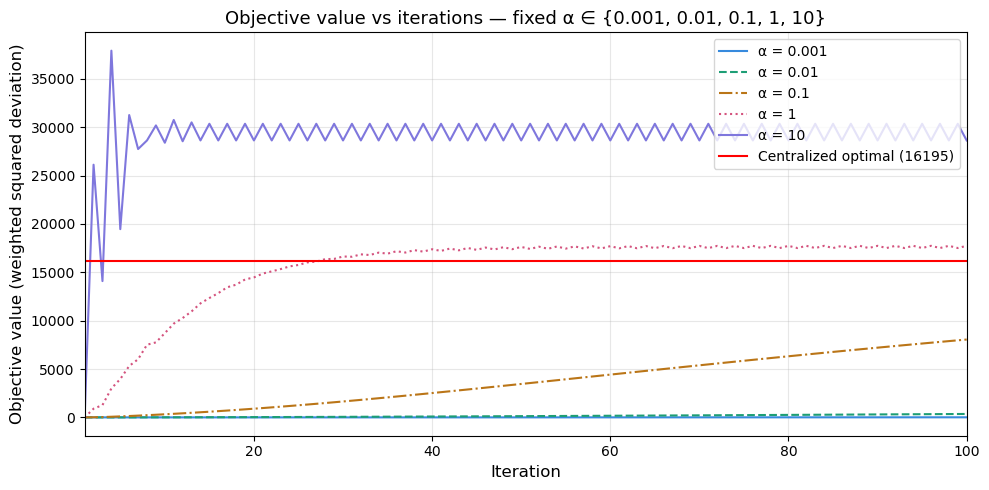

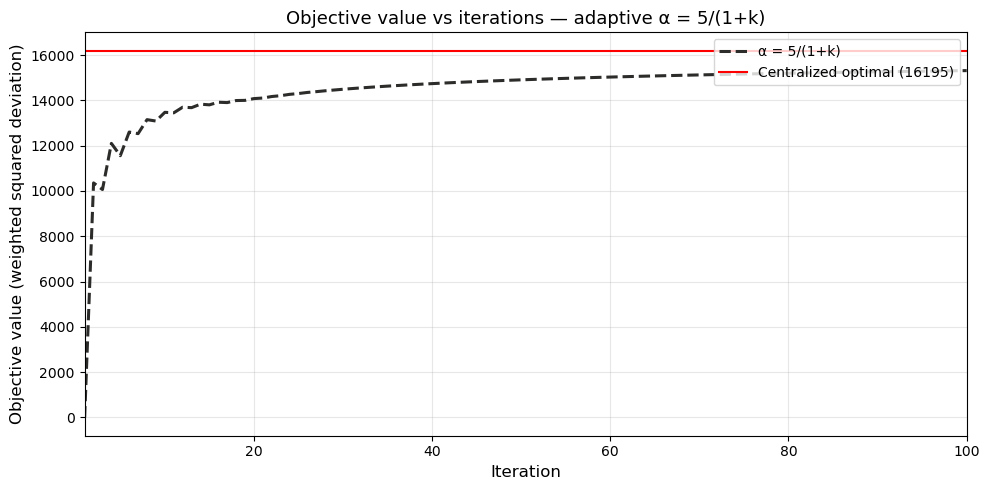

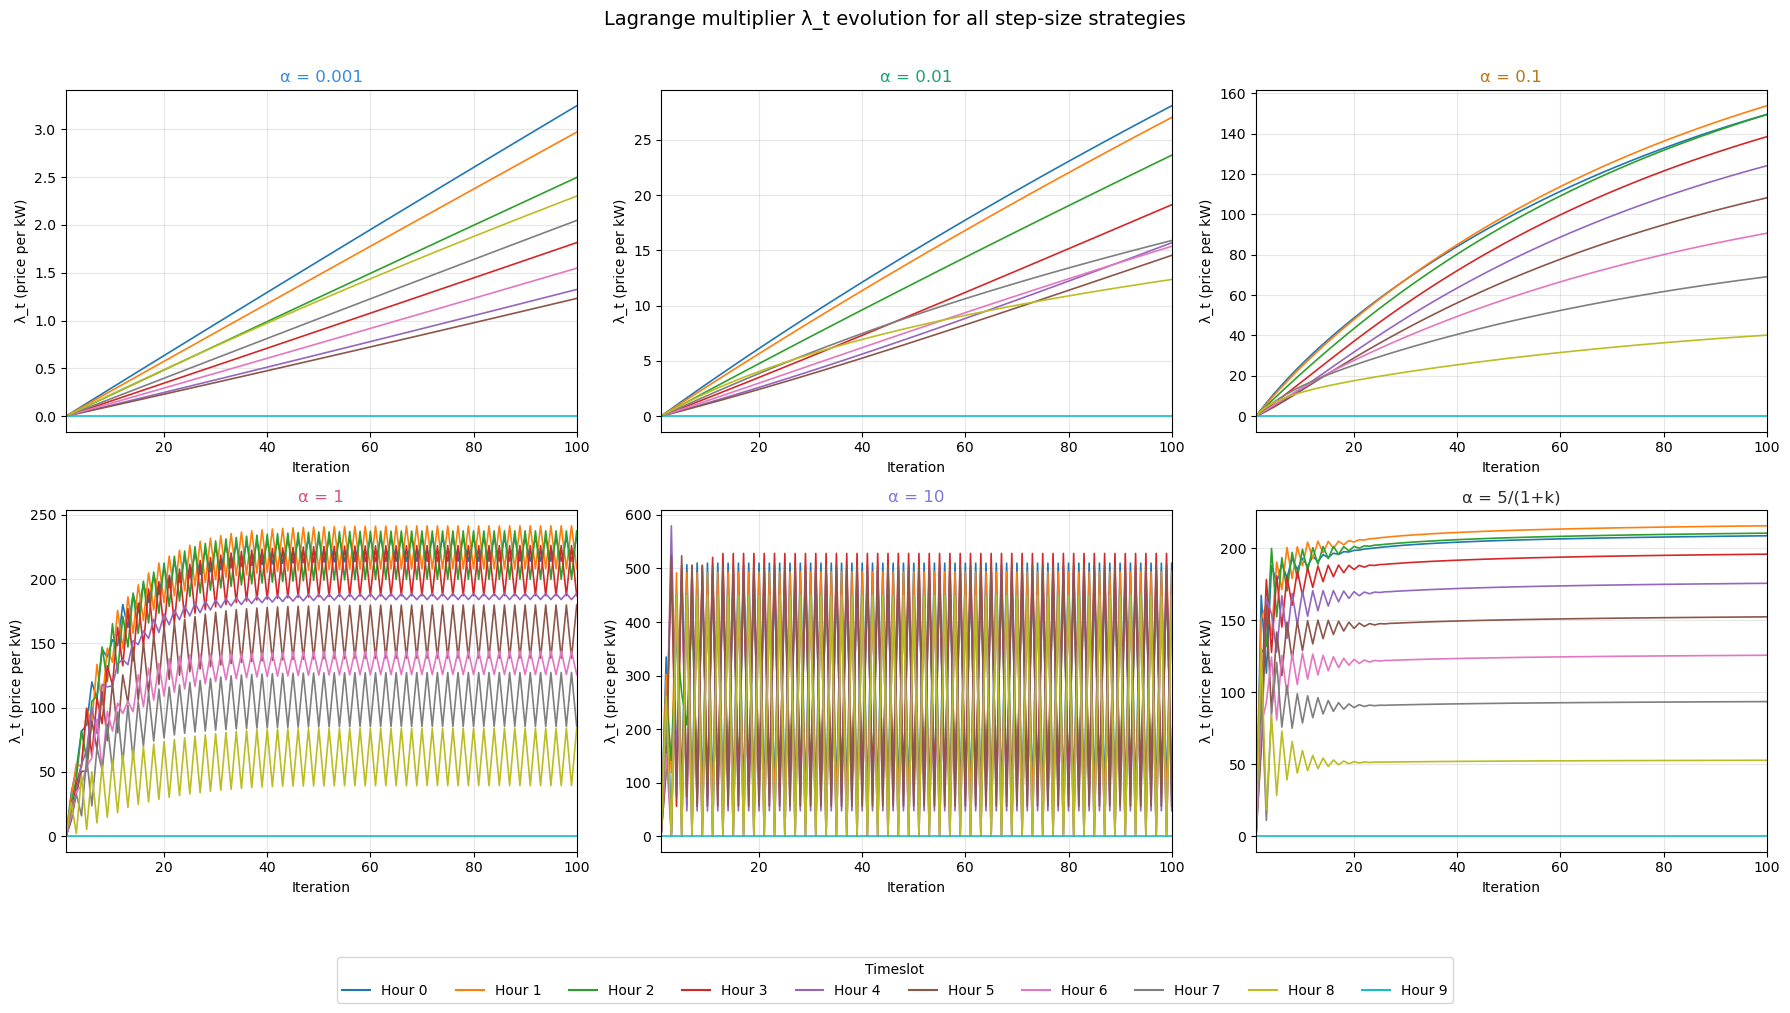

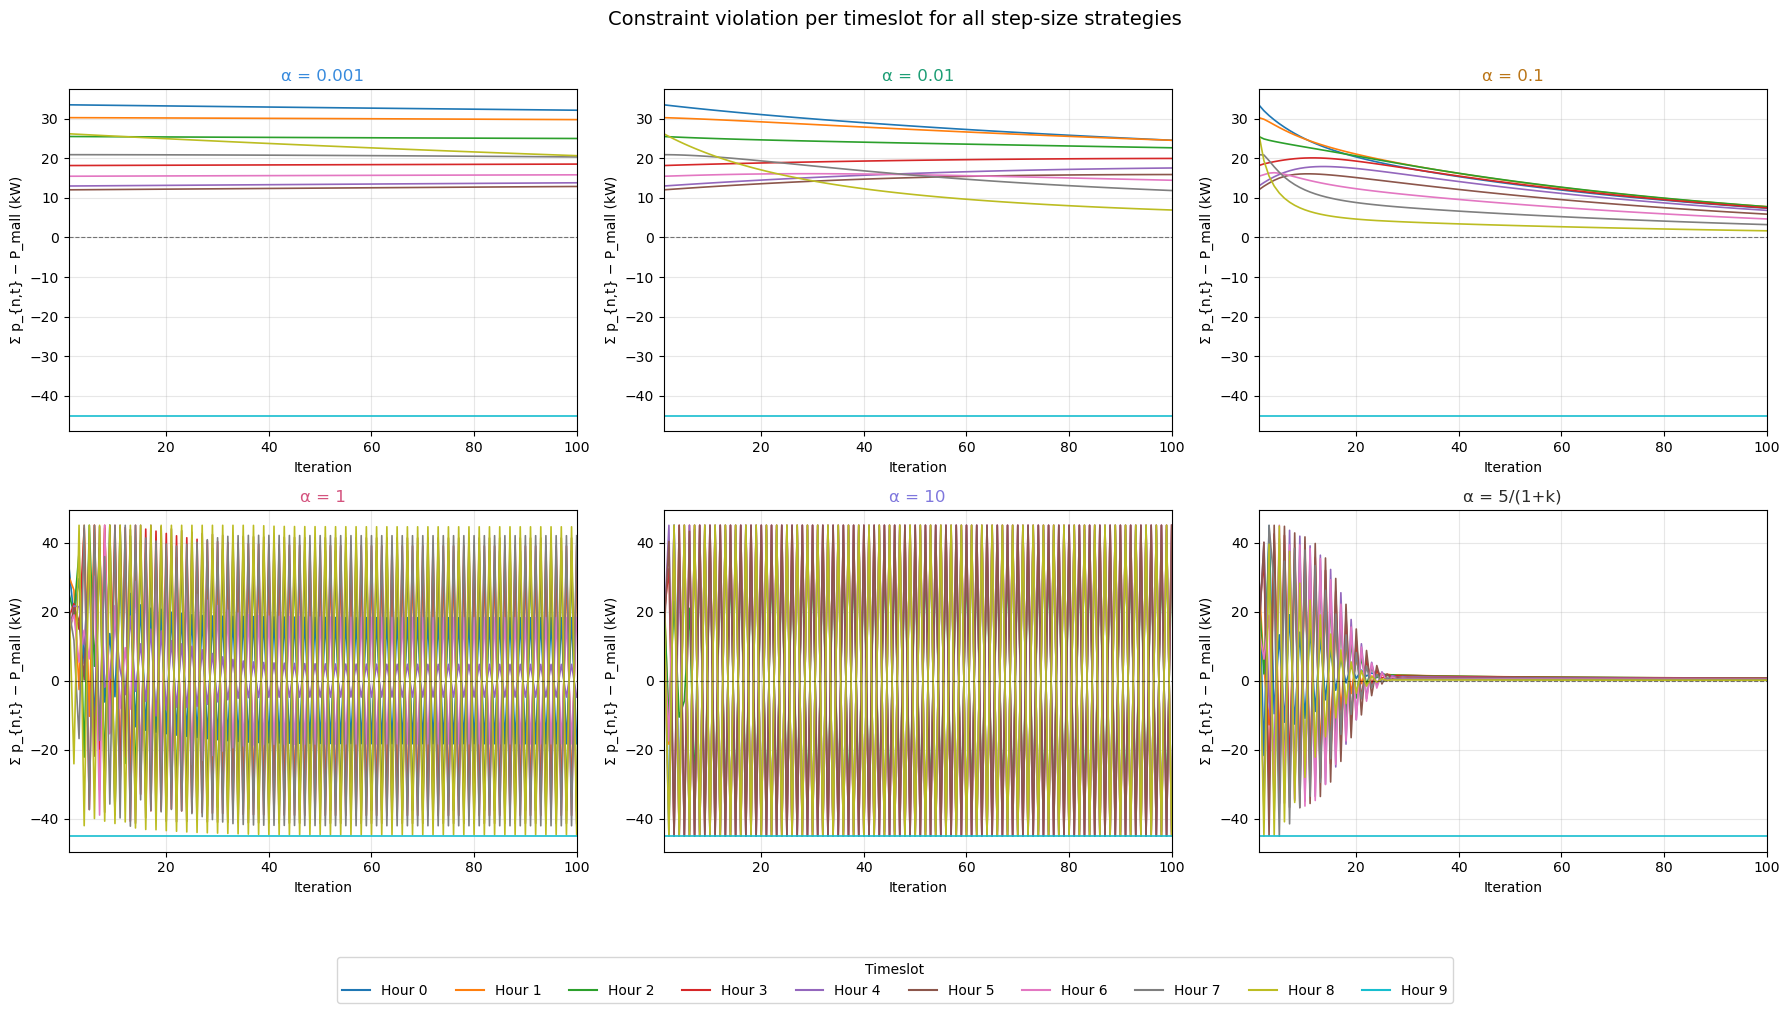


All figures saved as PNG.


In [41]:
data = load_data()

print("Loading data...")
print(f"  Stores:    {data['N']}")
print(f"  Hours:     {data['T']}")
print(f"  P_mall:    {data['P_mall']} kW")
print(f"  T_ref:     {data['T_ref']} °C")
print(f"  Weights:   {data['weights']}")
print()

obj_centralized, results = run_experiments(data, n_iterations=100)

# --- Export numerical results to Excel ---
export_results_to_excel('task7_results.xlsx', obj_centralized, results, data)

create_plots(obj_centralized, results, data)